In [2]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import os
from statsmodels.stats.anova import AnovaRM
import pingouin as pg
from scipy.stats import ttest_1samp, pearsonr, ttest_rel

ROOT =  Path().resolve().parent
sys.path.append(str(ROOT))

import globals as gl

plt.style.use('default')

Base directory found: /Users/mnlmrc/Library/CloudStorage/GoogleDrive-mnlmrc@unife.it/My Drive/UWO/SensoriMotorPrediction/
Base directory: /Users/mnlmrc/Library/CloudStorage/GoogleDrive-mnlmrc@unife.it/My Drive/UWO/SensoriMotorPrediction/
Atlases dir found: /Users/mnlmrc/Documents/GitHub/sensori-motor-prediction/data/atlases


# Demographics
## Experiment 1

In [6]:
experiment = 'smp2'
participants = pd.read_csv(os.path.join(ROOT, 'data', 'participants.tsv'), sep='\t')
participants_exp1 = participants[participants['Experiment'] == 1]
participants_exp2 = participants[participants['Experiment'] == 2]

demographics = {
    'Total Participants': len(participants_exp1),
    'Gender Distribution': participants_exp1['sex'].value_counts(),
    'Average Age': participants_exp1['age'].mean(),
    'SD Age': participants_exp1['age'].std(),
    'Age Range': (participants_exp1['age'].min(), participants_exp1['age'].max()),
    'Handedness Distribution': participants_exp1['handedness'].value_counts(),
}

# Print the summary
for key, value in demographics.items():
    print(f"{key}: {value}")

Total Participants: 14
Gender Distribution: sex
m    8
f    6
Name: count, dtype: int64
Average Age: 21.357142857142858
SD Age: 4.162232072359232
Age Range: (np.int64(18), np.int64(34))
Handedness Distribution: handedness
right    14
Name: count, dtype: int64


## Experiment 2

In [7]:
demographics = {
    'Total Participants': len(participants_exp2),
    'Gender Distribution': participants_exp2['sex'].value_counts(),
    'Average Age': participants_exp2['age'].mean(),
    'SD Age': participants_exp2['age'].std(),
    'Age Range': (participants_exp2['age'].min(), participants_exp2['age'].max()),
    'Handedness Distribution': participants_exp2['handedness'].value_counts(),
}

# Print the summary
for key, value in demographics.items():
    print(f"{key}: {value}")

Total Participants: 10
Gender Distribution: sex
M    8
F    2
Name: count, dtype: int64
Average Age: 25.7
SD Age: 3.7727090178455764
Age Range: (np.int64(21), np.int64(32))
Handedness Distribution: handedness
right    10
Name: count, dtype: int64


# Reaction time

In [6]:
filepath = os.path.join(ROOT, 'data', gl.behavDir, f'{experiment}_force_single_trial.tsv')
dat = pd.read_csv(filepath, sep='\t', )
dat = dat.groupby(['sn', 'GoNogo']).mean(numeric_only=True).reset_index()
RT = dat[dat['GoNogo']=='go'].RT
print(f'RT={RT.mean()}+/-{RT.std()}')

RT=0.16297010738886744+/-0.02124454320570604


# Force response aligned to perturbation (Fig. 1b)

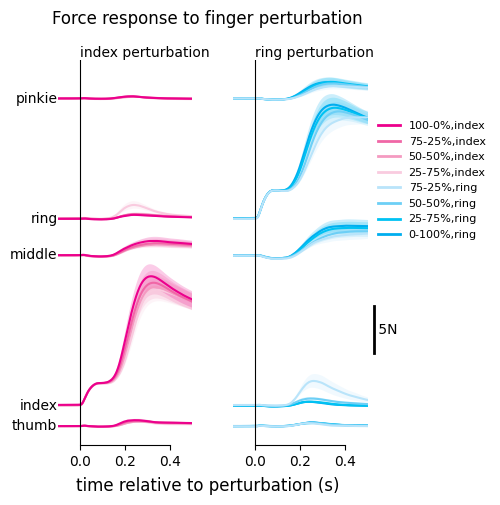

In [9]:
from vis import plot_aligned_force

npz = np.load(os.path.join(ROOT, 'data', gl.behavDir, 'force.segmented.avg.npz'), allow_pickle=True)
force = npz['data_array']
descr = pd.DataFrame(npz['descriptor'].item())
force = force[descr.GoNogo == 'go']
descr = descr[descr.GoNogo == 'go']
fig, axs = plt.subplots(1, 2, figsize=(4, 5), sharey=True, sharex=True)
plot_aligned_force(fig, axs, force, descr)
plt.show()

# Mean force response 0.2-0.4s from perturbation (Fig. 1c)

rmANOVA index perturbation
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue 21.1345 3.0000 39.0000 0.0000

rmANOVA ring perturbation
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue  6.1095 3.0000 39.0000 0.0016



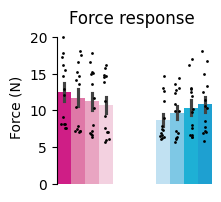

In [11]:
from vis import plot_binned_behaviour

fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))
filepath = os.path.join(ROOT, 'data', gl.behavDir, f'{experiment}_force_single_trial.tsv')
dat = pd.read_csv(filepath, sep='\t', )
dat = dat.groupby(['sn', 'cue', 'stimFinger', 'GoNogo', ]).mean(numeric_only=True).reset_index()
fig, axs = plot_binned_behaviour(fig, axs, dat, y=['index1', 'ring1'], finger=('index', 'ring'))
axs[0].spines[['left']].set_bounds(0, 20)
axs[0].set_ylabel('Force (N)')
fig.suptitle('Force response')

anova_index = AnovaRM(data=dat[dat['stimFinger']=='index'], depvar='index1', subject='sn', within=['cue'])
anova_ring = AnovaRM(data=dat[dat['stimFinger']=='ring'], depvar='ring1', subject='sn', within=['cue'])

result = anova_index.fit()
print('rmANOVA index perturbation')
print(result)

result = anova_ring.fit()
print('rmANOVA ring perturbation')
print(result)

plt.show()

# Force trajectories (Fig. 1d)

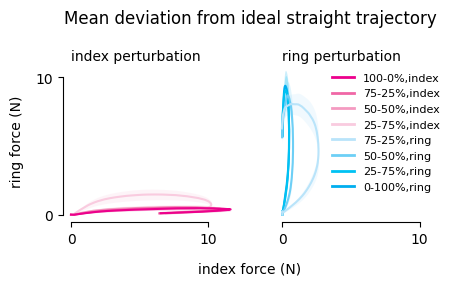

In [12]:
from vis import plot_aligned_deviation

fig, axs = plt.subplots(1, 2, figsize=(5, 2.75), sharey=True, sharex=True)
cut = .06 # skip first 60ms (no active force generated)
startSample = int(gl.prestim * gl.fsample_mov + cut * gl.fsample_mov)
force = force[:, startSample:]
force = force - force[:, 0][:, None]
plot_aligned_deviation(fig, axs, force, descr)

plt.show()

# Mean deviation from straight force trajectory (Fig. 1e)

Mean deviation for perturbation on cued vs. uncued finger
Index perturbation: t=2.744, p=0.008
Ring perturbation: t=3.201, p=0.003


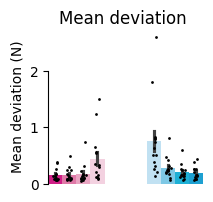

In [16]:
fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))
fig, axs = plot_binned_behaviour(fig, axs, dat, y=['MD', 'MD'], finger=('index', 'ring'))
axs[0].spines[['left']].set_bounds(0, 2)
axs[0].set_ylabel('Mean deviation (N)')

fig.suptitle('Mean deviation')

filepath = os.path.join(ROOT, 'data', gl.behavDir, f'{experiment}_force_single_trial.tsv')
dat_stat = pd.read_csv(filepath, sep='\t', )
dat_stat = dat_stat.groupby(['sn', 'stimFinger', 'Unexpected']).mean(numeric_only=True).reset_index()
dat_stat = dat_stat[dat_stat['Unexpected']>=0]

print('Mean deviation for perturbation on cued vs. uncued finger')
dat_stat_index = dat_stat[dat_stat['stimFinger']=='index']
x1 = dat_stat_index[dat_stat_index['Unexpected']==1].MD.to_numpy()
x0 = dat_stat_index[dat_stat_index['Unexpected']==0].MD.to_numpy()
tval, pval = ttest_1samp(x1 - x0, 0, alternative='greater')
print(f'Index perturbation: t={tval:.3f}, p={pval:.3f}')

dat_stat_index = dat_stat[dat_stat['stimFinger']=='ring']
x1 = dat_stat_index[dat_stat_index['Unexpected']==1].MD.to_numpy()
x0 = dat_stat_index[dat_stat_index['Unexpected']==0].MD.to_numpy()
tval, pval = ttest_1samp(x1 - x0, 0, alternative='greater')
print(f'Ring perturbation: t={tval:.3f}, p={pval:.3f}')

plt.show()

# Pre-activation before perturbation onset

rmANOVA index perturbation
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue  3.4133 4.0000 52.0000 0.0149

rmANOVA ring perturbation
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue  6.0417 4.0000 52.0000 0.0005



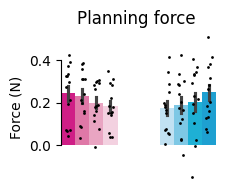

In [17]:
fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))
fig, axs = plot_binned_behaviour(fig, axs, dat, y=['index0', 'ring0'])
axs[0].spines[['left']].set_bounds(0, .4)
axs[0].set_ylabel('Force (N)')
fig.suptitle('Planning force')

anova_index = AnovaRM(data=dat[dat['stimFinger']=='nogo'], depvar='index0', subject='sn', within=['cue'])
anova_ring = AnovaRM(data=dat[dat['stimFinger']=='nogo'], depvar='ring0', subject='sn', within=['cue'])

result = anova_index.fit()
print('rmANOVA index perturbation')
print(result)

result = anova_ring.fit()
print('rmANOVA ring perturbation')
print(result)

plt.show()